In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

In [ ]:
# Load the 20 Newsgroups dataset
newsgroups = fetch_20newsgroups(subset="all", remove=("headers", "footers", "quotes"))

In [ ]:
# Vectorize the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.5, max_features=1000, stop_words="english")
tfidf_matrix = tfidf_vectorizer.fit_transform(newsgroups.data)

In [ ]:
# Reduce dimensionally using LSA (Latent Semantic Analysis)
lsa = TruncatedSVD(n_components=2)
lsa_matrix = lsa.fit_transform(tfidf_matrix)

In [ ]:
# Perform K-Means clustering
k = 20
model = KMeans(n_clusters=k, random_state=42)
model.fit(lsa_matrix)

KMeans(n_clusters=20, random_state=42)

**Elbow Method (to find best k)**

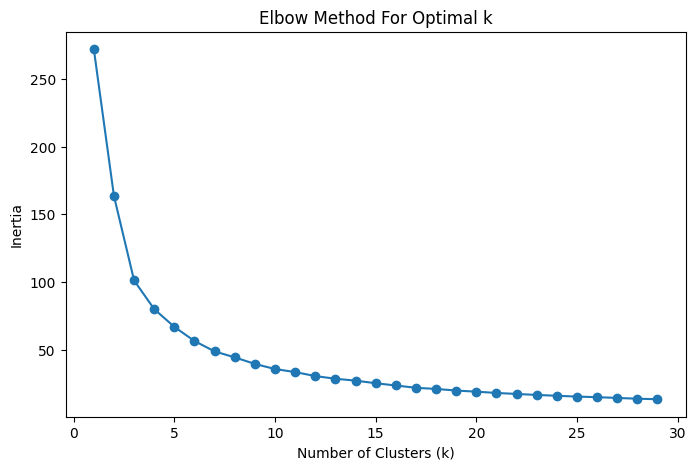

In [ ]:
inertia = []
k_values = range(1, 30)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(lsa_matrix)
    inertia.append(km.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal k")
plt.show()

**Final Clustering Visualization (2D plot)**

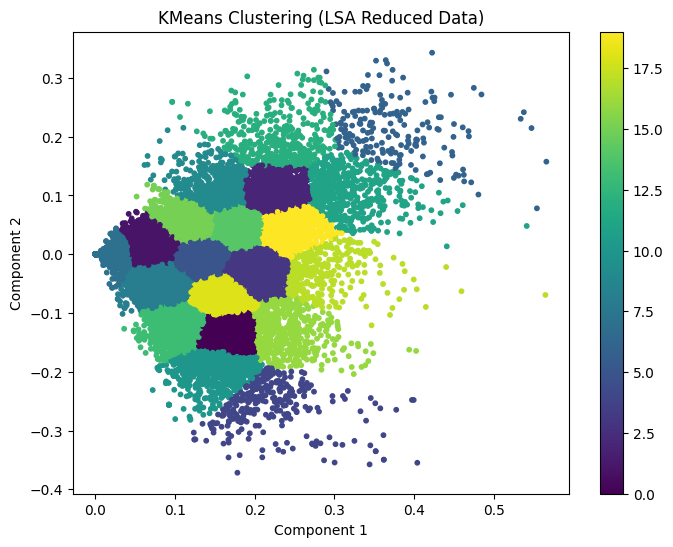

In [ ]:
# Predict clusters
labels = model.predict(lsa_matrix)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(lsa_matrix[:, 0], lsa_matrix[:, 1], c=labels, cmap='viridis', s=10)
plt.title("KMeans Clustering (LSA Reduced Data)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar()
plt.show()

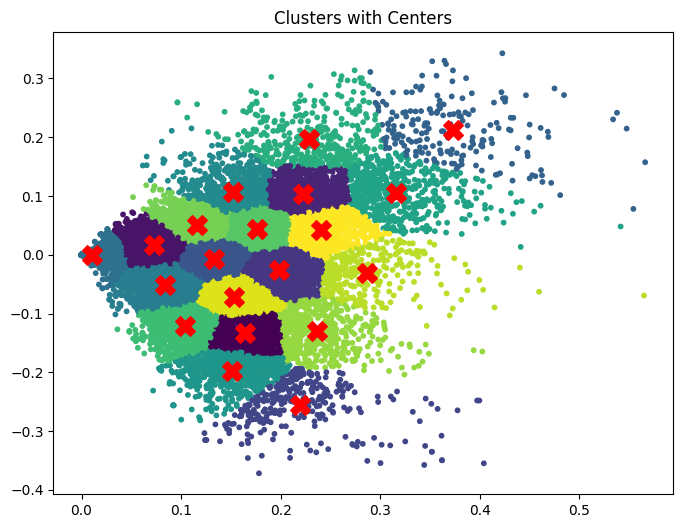

In [ ]:
centers = model.cluster_centers_

plt.figure(figsize=(8,6))
plt.scatter(lsa_matrix[:, 0], lsa_matrix[:, 1], c=labels, cmap='viridis', s=10)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
plt.title("Clusters with Centers")
plt.show()